chapter five: mining the black hole

in chapter two, i mentioned briefly (and then refused to elaborate) on the flack that black holes can be find and that theoretically, a sufficiently motivated civilization could extract energy from a spinning black hole. i said i wasn't taking questions.

well, i've procrastinated long enough, it's time to tackl the questions.

the premise is:  a kerr black hole carries enormous rotational energy - for a fast spinner, a sizeable fraction of its entire mass energy is stored in the spin. but everything inside the horizon is, by chapter four's scheduling argument, unreachable forever. so if any of that energy is extractable even in principle, it must be stored somewhere outside the horizon.

remember frame dragging? spacetime circulating around the hole like water around a drain? close enough in, the dragging becomes so strong that no amount of rocket power lets you hover at fixed position. you can still leave. you can still scream. but you cannot stand still. this region inside the building, outside the vault, is called the <b>ergosphere</b>, from the greek <i>ergon</i>: work. the name insinuates that this is the room where work gets done.

on the horizon, every future points inward. on the ergosphere, every future points around. 

the ergosphere's outer boundary, the static limit, is where standing still first becomes impossible. this is at,

$$r_E(\theta) = M + \sqrt{M^2 - a^2\cos^2\theta}$$

compare the horizon, $r_+ = M + \sqrt{M^2 - a^2}$. they touch at the poles and gape apart at the equator, where $r_E = 2M$ always regardless of spin. so the lobby is a pumpkin-shaped shell wrapped around the horizon: widest at the equator (where the dragging does its work), vanishing at the poles (nothing drags along the spin axis).

for a lazy spinner (a fond nickname i've given to our chapter two hole), and a nearly maximal one,

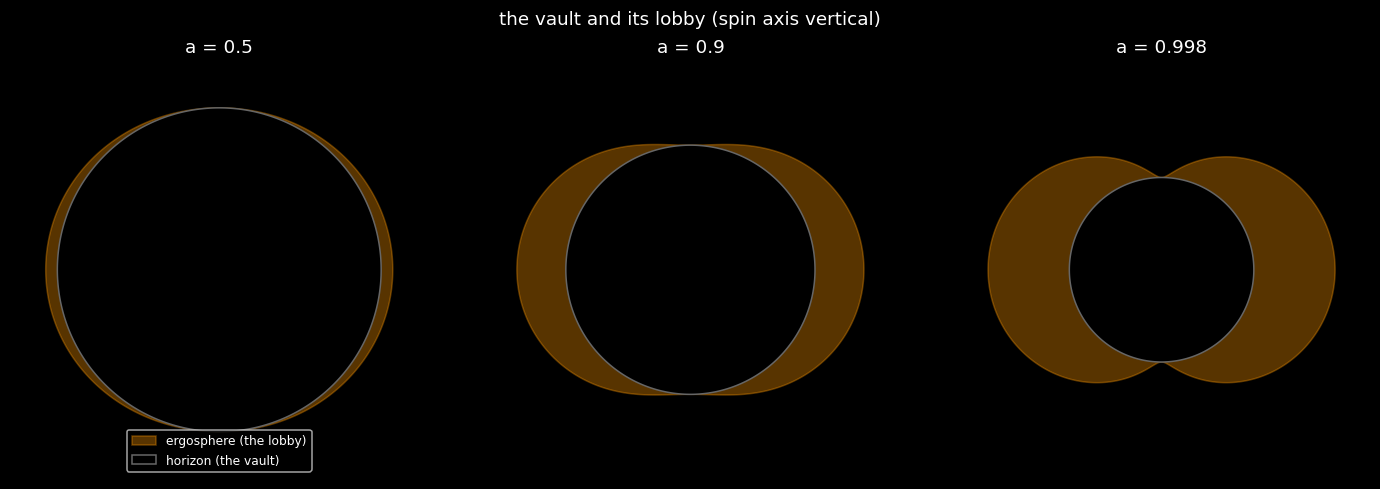

In [2]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# geometrized units. the usual arrangement
M = 1.0     
plt.rcParams['figure.dpi'] = 110

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), facecolor='black')
th = np.linspace(0, 2*np.pi, 400)
for ax, a in zip(axes, [0.5, 0.9, 0.998]):
    r_hor = M + np.sqrt(M**2 - a**2)
    r_erg = M + np.sqrt(M**2 - a**2*np.cos(th)**2)
    # meridional cross-section: x = r sin(theta), z = r cos(theta)
    ax.fill(r_erg*np.sin(th), r_erg*np.cos(th), color='#ff9800', alpha=0.35,
            label='ergosphere (the lobby)')
    ax.fill(r_hor*np.sin(th), r_hor*np.cos(th), color='black', edgecolor='#666',
            label='horizon (the vault)')
    ax.set_title(f"a = {a}", color='white')
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
    ax.set_aspect('equal'); ax.axis('off')
axes[0].legend(loc='lower center', facecolor='black', labelcolor='white', fontsize=8)
fig.suptitle("the vault and its lobby (spin axis vertical)", color='white', y=1.0)
plt.tight_layout(); plt.show()

notice how the spin causes the vault to shrink? while the notice what spin does: the vault shrinks (chapter two told us that) while the lobby's equator stays pinned at $2M$ so faster holes have "roomier" lobbies. at $a = 0.998$ there's a thick orange working region wrapped around a small horizon. the heist happens in the orange.

"you cannot stand still" deserves to be computed, not just asserted. consider hovering at radius $r$ in the equatorial plane, circling with some angular velocity $\Omega = d\phi/dt$. for your worldline to be physical (timelike, inside your own light cone, chapter one!), $\Omega$ must lie between the two light values,

$$\Omega_\pm = \frac{-g_{t\phi} \pm \sqrt{g_{t\phi}^2 - g_{tt}\,g_{\phi\phi}}}{g_{\phi\phi}}$$

these are the angular velocities of photons sent with and against the rotation. your allowed band is everything strictly between them,

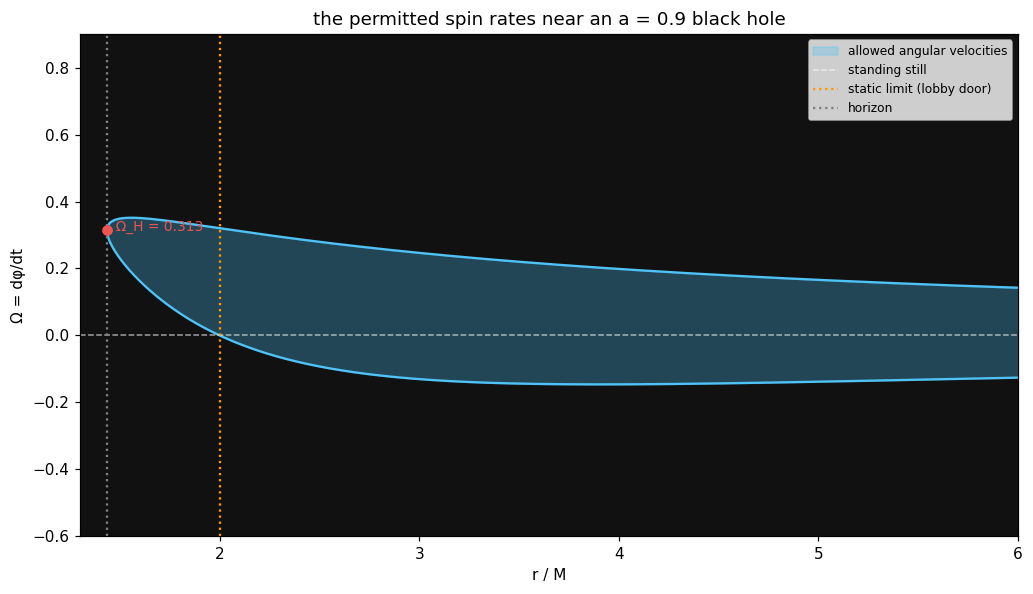

In [4]:
# same hole as chapter two
a = 0.9                       
r_h  = M + np.sqrt(M**2 - a**2)
g_tt = lambda r: -(1 - 2*M/r)
g_tp = lambda r: -2*M*a/r
g_pp = lambda r: r**2 + a**2 + 2*M*a**2/r

r = np.linspace(r_h + 1e-4, 6, 800)
disc = np.sqrt(g_tp(r)**2 - g_tt(r)*g_pp(r))
Om_minus = (-g_tp(r) - disc) / g_pp(r)
Om_plus  = (-g_tp(r) + disc) / g_pp(r)
# the horizon's own angular velocity
Om_H = a / (2*M*r_h)          

plt.figure(figsize=(9.5, 5.5))
plt.fill_between(r, Om_minus, Om_plus, color='#4fc3f7', alpha=0.3,
                 label='allowed angular velocities')
plt.plot(r, Om_minus, color='#4fc3f7', lw=1.5)
plt.plot(r, Om_plus, color='#4fc3f7', lw=1.5)
plt.axhline(0, color='white', lw=1, ls='--', alpha=0.6, label='standing still')
plt.axvline(2*M, color='#ff9800', ls=':', label='static limit (lobby door)')
plt.axvline(r_h, color='gray', ls=':', label='horizon')
plt.plot(r_h, Om_H, 'o', color='#ef5350', zorder=5)
plt.annotate(f'  Ω_H = {Om_H:.3f}', (r_h, Om_H), color='#ef5350', fontsize=9)
plt.xlabel('r / M'); plt.ylabel('Ω = dφ/dt')
plt.ylim(-0.6, 0.9); plt.xlim(1.3, 6)
plt.title(f'the permitted spin rates near an a = {a} black hole')
plt.legend(fontsize=8)
plt.gca().set_facecolor('#111'); plt.gcf().patch.set_facecolor('white')
plt.tight_layout(); plt.show()

this graph is meant to be read right to left, riding inward. 

at the <b>static limit</b>, the band's lower edge touches zero, standing still is now achievable only by a photon aimed flat out against the spin, which is a poetic way of saying: not by you. inside, the entire band lifts off zero. every permitted motion has $\Omega > 0$. rotating with the hole stops being a choice and becomes a fact about your future, exactly like falling was in chapter four.

and at the horizon the band pinches shut to a single value, $\Omega_H = \frac{a}{2Mr_+}$, the black hole's own rotation rate. the vault door spins, and at the threshold, so must everything, at exactly its speed. (this "the horizon rotates rigidly, like a solid door" fact will matter enormously when we get to black hole thermodynamics. foreshadowing.)

now i'm going to talk about something weird.

the "energy" we've used all series, the conserved $E$ of chapters one through four, is energy as accounted from far away. it's the bookkeeping entry that tells the distant universe what you're worth, your rest mass, plus kinetic, minus the (negative) gravitational binding. deep in a gravity well, your ledger value $E$ is less than your local worth. 

but inside the ergosphere, where the dragging is total, something becomes possible that is flatly impossible everywhere else: orbits with $E < 0$. negative energy, as accounted from infinity. not negative locally, an observer flying past such a particle measures perfectly ordinary positive energy, it's a normal particle, but its entry in the universe's far away ledger is a debt.

two rules about the debt:
* it can only exist inside the lobby. carry it toward the static limit and the books stop balancing, a negative energy particle literally cannot exit the ergosphere. it's trapped
* which leaves it exactly one destination. eventually, it must fall into the vault. and when it does, the vault's balance decreases.

(a fun implementation note: when i first coded the search for these orbits, i forgot to require that the particles move forward in time, and the maths cheerfully handed me a zoo of negative energy states everywhere. always check your particles aren't time travellers before publishing lmao)

you can see the heist assembling itself. we can't take energy out of the hole. but we can arrange for the hole to swallow a debt.


now, i'll tell you the plan for my next code snippet.

1. let's throw a rock into the lobby
2. at the 

In [6]:
# equatorial kerr geodesics for arbitrary (specific) energy e and ang. momentum l
rr, ee, ll, aa = sp.symbols('r e l a', positive=False, real=True)
Dlt = rr**2 - 2*rr + aa**2
gtt_s = -((rr**2+aa**2)**2 - aa**2*Dlt) / (rr**2*Dlt)      # inverse metric, equatorial
gtp_s = -2*aa / (rr*Dlt)
gpp_s = (Dlt - aa**2) / (rr**2*Dlt)
grr_s = Dlt / rr**2

# (dr/dtau)^2
Rpot   = grr_s * (-1 - (gtt_s*ee**2 - 2*gtp_s*ee*ll + gpp_s*ll**2))  
# d2r/dtau2 
rddot  = sp.diff(Rpot, rr) / 2                                        
phidot = gpp_s*ll - gtp_s*ee

R_f    = sp.lambdify((rr, ee, ll, aa), Rpot,   'numpy')
acc_f  = sp.lambdify((rr, ee, ll, aa), rddot,  'numpy')
phid_f = sp.lambdify((rr, ee, ll, aa), phidot, 'numpy')
print("geodesics derived. sign errors: zero")

def geodesic(r0, rdot0, phi0, e, l, a, tau_max, stop_in=None, stop_out=None):
    def rhs(t, y): return [y[1], acc_f(y[0], e, l, a), phid_f(y[0], e, l, a)]
    evs = []
    if stop_in:  evi = lambda t, y: y[0] - stop_in;  evi.terminal = True; evs.append(evi)
    if stop_out: evo = lambda t, y: y[0] - stop_out; evo.terminal = True; evs.append(evo)
    s = solve_ivp(rhs, (0, tau_max), [r0, rdot0, phi0], events=evs,
                  rtol=1e-10, atol=1e-12, max_step=0.05)
    return s.y[0], s.y[2]

geodesics derived. sign errors: zero


In [7]:
# ---- the robbery, in code ----
a   = 0.998                              # the fast one
r_h = M + np.sqrt(M**2 - a**2)
Dl   = lambda r: r*r - 2*r + a*a
gtt_i = lambda r: -((r*r+a*a)**2 - a*a*Dl(r)) / (r*r*Dl(r))    # inverse metric pieces
gtp_i = lambda r: -2*a / (r*Dl(r))
gpp_i = lambda r: (Dl(r) - a*a) / (r*r*Dl(r))
grr_i = lambda r: Dl(r) / (r*r)
g_cov = lambda r: np.array([[-(1-2/r), 0, -2*a/r],
                            [0, r*r/Dl(r), 0],
                            [-2*a/r, 0, r*r+a*a+2*a*a/r]])
Rdot2 = lambda r,e,l: grr_i(r)*(-1 - (gtt_i(r)*e*e - 2*gtp_i(r)*e*l + gpp_i(r)*l*l))

# the rock: unit mass, hurled in with a touch of extra energy, aimed to arrive at the
# split point *slowly* (small radial speed = an easy target for the explosion to redirect)
E0, L0   = 1.010, 2.200
r_split  = 1.3                           # deep in the lobby (horizon: 1.063)
u0 = np.array([-gtt_i(r_split)*E0 + gtp_i(r_split)*L0,      # the rock's 4-velocity there
               -np.sqrt(Rdot2(r_split, E0, L0)),
               gpp_i(r_split)*L0 - gtp_i(r_split)*E0])

# explosion directions: orthonormal frame orthogonal to the rock's own 4-velocity
g = g_cov(r_split)
def orthonormal(X, others):
    Y = X + (X @ g @ u0) * u0            # project out u0 (u0.u0 = -1)
    for o in others:
        Y = Y - (Y @ g @ o) * o
    return Y / np.sqrt(Y @ g @ Y)
e_out  = orthonormal(np.array([0., 1., 0.]), [])         # local "outward"
e_spin = orthonormal(np.array([0., 0., 1.]), [e_out])    # local "with the spin"
if e_out[1] < 0: e_out = -e_out

# detonate: fragments at v = 0.99c, mostly along the spin axis of motion, with a
# slight outward tilt (the getaway needs a head start against the infall)
v_boom, beta = 0.99, np.radians(3)
e_hat = np.cos(beta)*e_spin + np.sin(beta)*e_out
gam = 1/np.sqrt(1 - v_boom**2)
mu  = 1/(2*gam)                          # each fragment's rest mass; the blast eats the rest
p1  = mu*gam*(u0 - v_boom*e_hat)         # fragment 1: hurled against the spin (and inward)
p2  = mu*gam*(u0 + v_boom*e_hat)         # fragment 2: with the spin (and outward)

(E1, L1), (E2, L2) = [(-(g@p)[0], (g@p)[2]) for p in (p1, p2)]
print(f"the rock arrives with        E0 = {E0:+.4f}")
print(f"fragment 1 (the debt):       E1 = {E1:+.4f}   L1 = {L1:+.3f}   <- negative energy!")
print(f"fragment 2 (the getaway):    E2 = {E2:+.4f}   L2 = {L2:+.3f}")
print(f"\nenergy out vs energy in: {E2:.4f} vs {E0:.4f}  ->  the hole just paid us {100*(E2-E0)/E0:.1f}%")

the rock arrives with        E0 = +1.0100
fragment 1 (the debt):       E1 = -0.1119   L1 = -0.387   <- negative energy!
fragment 2 (the getaway):    E2 = +1.1219   L2 = +2.587

energy out vs energy in: 1.1219 vs 1.0100  ->  the hole just paid us 11.1%


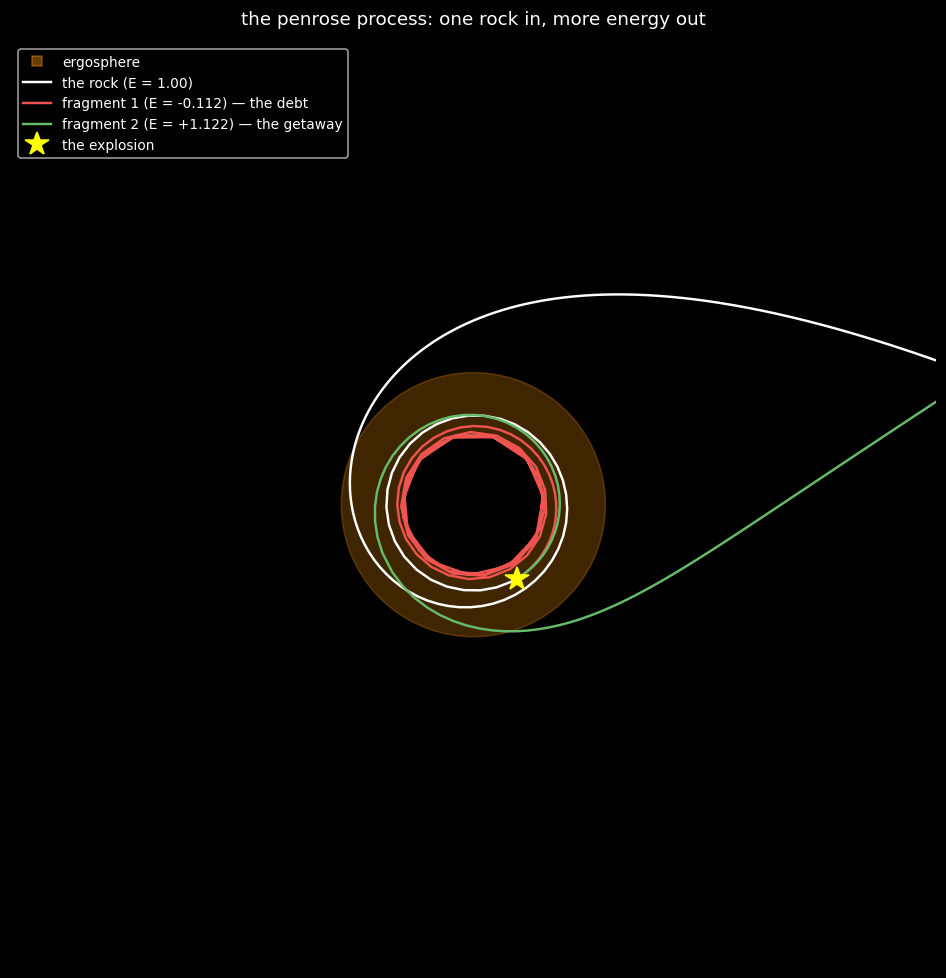

: 

In [ ]:
# sim szn
rock_r,  rock_ph  = geodesic(12.0, -np.sqrt(R_f(12.0, E0, L0, a)), 0.0, E0, L0, a,
                             500, stop_in=r_split*1.0001)
ph_s = rock_ph[-1]
f1_r, f1_ph = geodesic(r_split, p1[1]/mu, ph_s, E1/mu, L1/mu, a, 200, stop_in=r_h*1.002)
f2_r, f2_ph = geodesic(r_split, p2[1]/mu, ph_s, E2/mu, L2/mu, a, 1000, stop_out=12.0)

fig, ax = plt.subplots(figsize=(9, 9), facecolor='black')
ax.set_facecolor('black')
th = np.linspace(0, 2*np.pi, 200)

# lobby (equatorial)
ax.fill(2*M*np.cos(th), 2*M*np.sin(th), color='#ff9800', alpha=0.25)   
ax.fill(r_h*np.cos(th), r_h*np.sin(th), color='black', edgecolor='#666')
ax.plot([], [], 's', color='#ff9800', alpha=0.4, label='ergosphere')

for rr_, pp_, colr, lbl in [(rock_r, rock_ph, 'white',   'the rock (E = 1.00)'),
                            (f1_r,  f1_ph,  '#ef5350', f'fragment 1 (E = {E1:+.3f}) — the debt'),
                            (f2_r,  f2_ph,  '#66bb6a', f'fragment 2 (E = {E2:+.3f}) — the getaway')]:
    ax.plot(rr_*np.cos(pp_), rr_*np.sin(pp_), color=colr, lw=1.6, label=lbl)
ax.plot(r_split*np.cos(ph_s), r_split*np.sin(ph_s), '*', color='yellow', ms=16,
        label='the explosion', zorder=5)
ax.set_xlim(-7, 7); ax.set_ylim(-7, 7)
ax.set_aspect('equal'); ax.axis('off')
ax.legend(facecolor='black', labelcolor='white', fontsize=9, loc='upper left')
ax.set_title('the penrose process: one rock in, more energy out', color='white', pad=12)
plt.tight_layout(); plt.show()

In [9]:
k = 0.01     # our rock is a test particle: scale the transaction down accordingly
Mirr = lambda Mm, astar: np.sqrt(0.5*Mm**2*(1 + np.sqrt(max(1 - astar**2, 0))))

M_new = M + k*E1
J_new = a*M**2 + k*L1
a_new = J_new / M_new**2
print(f"mass:              {M:.5f}  ->  {M_new:.5f}   (down: we stole it)")
print(f"spin a*:           {a:.5f}  ->  {a_new:.5f}   (down: that's where it came from)")
print(f"irreducible mass:  {Mirr(M, a):.6f}  ->  {Mirr(M_new, a_new):.6f}   (UP)")

mass:              1.00000  ->  0.99888   (down: we stole it)
spin a*:           0.99800  ->  0.99636   (down: that's where it came from)
irreducible mass:  0.729114  ->  0.735822   (UP)


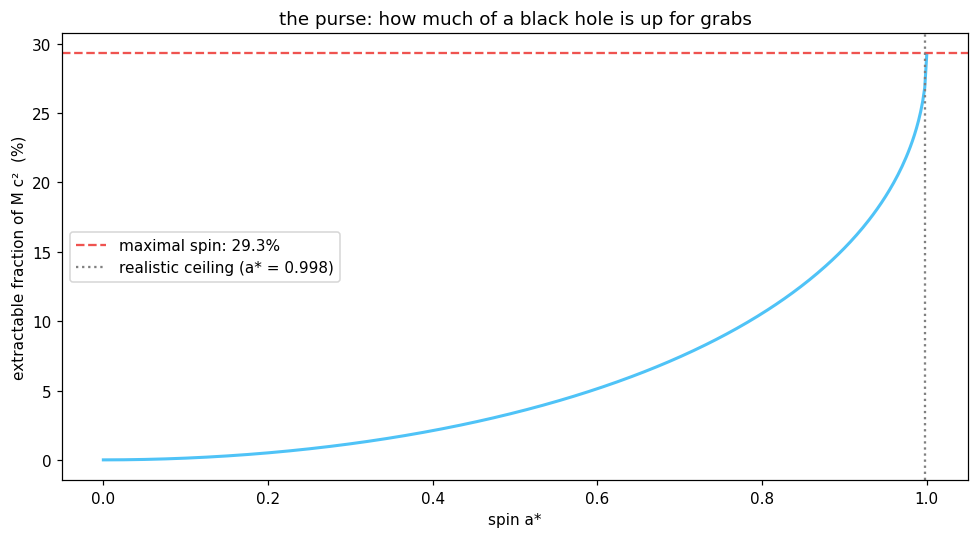

sagittarius a* at a* = 0.998: extractable energy = 2.1e+53 J
that is roughly 1.7e+09 entire solar lifetimes of output


In [10]:
astar = np.linspace(0, 1, 400)
frac = 1 - np.sqrt(0.5*(1 + np.sqrt(1 - astar**2)))

plt.figure(figsize=(9, 5))
plt.plot(astar, 100*frac, color='#4fc3f7', lw=2)
plt.axhline(100*(1 - 1/np.sqrt(2)), color='#ef5350', ls='--',
            label=f'maximal spin: {100*(1-1/np.sqrt(2)):.1f}%')
plt.axvline(0.998, color='gray', ls=':', label='realistic ceiling (a* = 0.998)')
plt.xlabel('spin a*'); plt.ylabel('extractable fraction of M c²  (%)')
plt.title('the purse: how much of a black hole is up for grabs')
plt.legend(); plt.tight_layout(); plt.show()

# price up sagittarius a*, generously spun up
Msun_kg, c = 1.989e30, 2.998e8
m_sgra = 4.3e6 * Msun_kg
f998 = 1 - np.sqrt(0.5*(1 + np.sqrt(1 - 0.998**2)))
loot = f998 * m_sgra * c**2
sun_lifetime = 3.8e26 * (10e9 * 3.15e7)          # total energy the sun will ever radiate
print(f"sagittarius a* at a* = 0.998: extractable energy = {loot:.1e} J")
print(f"that is roughly {loot/sun_lifetime:.1e} entire solar lifetimes of output")